# Bài toán 1 – Dự báo doanh thu theo ngày bằng RNN / LSTM / GRU (Keras (TensorFlow))

**Dữ liệu:** *E-commerce Customer Data For Behavior Analysis* (Kaggle) – bảng giao dịch, mỗi dòng là một giao dịch.

**Ý tưởng:** dữ liệu gốc là dạng bảng nên trước hết **tổng hợp theo ngày** thành chuỗi thời gian đa biến (doanh thu, số đơn, giá trị đơn trung bình, tỷ lệ trả hàng, đặc trưng lịch). Sau đó dùng cửa sổ trượt `WINDOW` ngày để dự đoán các đại lượng của **ngày kế tiếp**, và so sánh ba kiến trúc `RNN`, `LSTM`, `GRU` với hai mô hình cơ sở (Naive, trung bình 7 ngày).

**Quy trình:** 1) Nạp và kiểm tra dữ liệu → 2) Phân tích khám phá (EDA) → 3) Tạo chuỗi thời gian, kiểm tra cấu trúc → 4) Chia theo thời gian, chuẩn hóa, tạo cửa sổ → 5) Baseline → 6) Huấn luyện 3 mô hình → 7) Đánh giá và trực quan hóa → 8) Phân tích đặc trưng → 9) Dự báo tương lai → 10) Kết luận.

> **Lưu ý:** đây là dữ liệu **tổng hợp** (tên, tuổi, giới tính sinh bằng Faker). Nếu chuỗi doanh thu gần như nhiễu ngẫu nhiên thì việc RNN không vượt được baseline là kết quả bình thường, không phải lỗi code.

## 0. Thư viện và cấu hình

In [1]:
import os, glob, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (11, 4),
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold",
})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 30)

In [2]:
# ======================== CẤU HÌNH (có thể chỉnh) ========================
DATA_PATH   = "../data/ecommerce_customer_data_large.csv"   # <-- đường dẫn tới tệp CSV đã tải về
WINDOW      = 30      # số ngày lịch sử đưa vào RNN
HORIZON     = 14      # số ngày dự báo tương lai
TRAIN_RATIO = 0.70    # tỷ lệ tập huấn luyện (theo thời gian)
VAL_RATIO   = 0.15    # tỷ lệ tập kiểm định; phần còn lại là tập kiểm thử

UNITS       = 64      # số đơn vị ẩn mỗi lớp
DROPOUT     = 0.2
LR          = 1e-3
BATCH_SIZE  = 32
EPOCHS      = int(os.environ.get("NB_EPOCHS", 100))   # tối đa; có dừng sớm nên thường ít hơn
PATIENCE    = 12
SEED        = 42

In [3]:
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
print("Thiết bị:", [d.name for d in tf.config.list_physical_devices()])

TensorFlow: 2.21.0 | Keras: 3.15.1
Thiết bị: ['/physical_device:CPU:0']


In [4]:
def find_data_file(path, pattern):
    """Trả về đường dẫn tệp dữ liệu. Nếu DATA_PATH không tồn tại thì tự tìm theo mẫu tên trong thư mục hiện tại."""
    if os.path.exists(path):
        return path
    found = glob.glob(pattern) + glob.glob(os.path.join("**", pattern), recursive=True)
    found = sorted(set(found), key=lambda p: ("large" not in p.lower(), len(p), p))
    if not found:
        raise FileNotFoundError(
            f"Không tìm thấy '{path}'. Hãy sửa biến DATA_PATH ở ô cấu hình thành đường dẫn tới tệp CSV đã tải về.")
    print(f"Không thấy '{path}', tự động dùng: {found[0]}")
    return found[0]

def acf(x, nlags):
    """Hàm tự tương quan (ACF) tính trực tiếp bằng numpy."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    d = np.dot(x, x)
    return np.array([np.dot(x[:len(x) - k], x[k:]) / d for k in range(nlags + 1)])

def plot_acf(ax, x, nlags, title):
    a = acf(x, nlags)
    conf = 1.96 / np.sqrt(len(x))
    ax.bar(range(nlags + 1), a, width=0.3, color="#2F5496")
    ax.axhline(conf, ls="--", c="r", lw=1); ax.axhline(-conf, ls="--", c="r", lw=1)
    ax.axhline(0, c="k", lw=0.8)
    ax.set_title(title); ax.set_xlabel("Độ trễ (lag)"); ax.set_ylabel("ACF")
    return a, conf

## 1. Nạp dữ liệu và kiểm tra chất lượng

In [5]:
DATA_PATH = find_data_file(DATA_PATH, "ecommerce*.csv")
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

required = ["Purchase Date", "Total Purchase Amount"]
missing_cols = [c for c in required if c not in df.columns]
assert not missing_cols, f"Thiếu cột bắt buộc: {missing_cols}. Các cột hiện có: {list(df.columns)}"

df["Purchase Date"] = pd.to_datetime(df["Purchase Date"], errors="coerce")
df["Total Purchase Amount"] = pd.to_numeric(df["Total Purchase Amount"], errors="coerce")
if "Returns" in df.columns:
    df["Returns"] = pd.to_numeric(df["Returns"], errors="coerce")
n_bad = df["Purchase Date"].isna().sum() + df["Total Purchase Amount"].isna().sum()
df = df.dropna(subset=["Purchase Date", "Total Purchase Amount"]).reset_index(drop=True)

print(f"Số dòng (giao dịch): {len(df):,} | Số cột: {df.shape[1]}")
print(f"Khoảng thời gian: {df['Purchase Date'].min().date()} -> {df['Purchase Date'].max().date()}")
if "Customer ID" in df.columns:
    print(f"Số khách hàng duy nhất: {df['Customer ID'].nunique():,}")
print(f"Dòng bị loại vì thiếu ngày/số tiền: {n_bad}")
display(df.head())
display(df.dtypes.to_frame("Kiểu dữ liệu").T)

Số dòng (giao dịch): 250,000 | Số cột: 13
Khoảng thời gian: 2020-01-01 -> 2023-09-13
Số khách hàng duy nhất: 49,661
Dòng bị loại vì thiếu ngày/số tiền: 0


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0000,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0000,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0000,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0000,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0000,John Rivera,31,Female,0


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
Kiểu dữ liệu,int64,datetime64[us],str,int64,int64,int64,str,int64,float64,str,int64,str,int64


In [6]:
# --- Chất lượng dữ liệu ---
na = df.isna().mean().mul(100).round(2)
print("Tỷ lệ giá trị thiếu theo cột (%):"); display(na[na > 0].to_frame("% thiếu").T if (na > 0).any() else "Không có giá trị thiếu")
print("Số dòng trùng lặp hoàn toàn:", df.duplicated().sum())

if {"Product Price", "Quantity"} <= set(df.columns):
    diff = (pd.to_numeric(df["Product Price"], errors="coerce") * pd.to_numeric(df["Quantity"], errors="coerce")
            - df["Total Purchase Amount"]).abs()
    print(f"Tỷ lệ dòng mà Total != Price x Quantity: {(diff > 1e-6).mean():.2%}  (nếu cao, cần chọn cột tiền đáng tin)")

if {"Customer ID", "Churn"} <= set(df.columns):
    n_lab = df.groupby("Customer ID")["Churn"].nunique()
    print(f"Khách có nhãn Churn không nhất quán giữa các giao dịch: {(n_lab > 1).mean():.2%}")

display(df["Total Purchase Amount"].describe().to_frame("Total Purchase Amount").T)

Tỷ lệ giá trị thiếu theo cột (%):


,Returns
% thiếu,18.9500


Số dòng trùng lặp hoàn toàn: 0
Tỷ lệ dòng mà Total != Price x Quantity: 99.98%  (nếu cao, cần chọn cột tiền đáng tin)
Khách có nhãn Churn không nhất quán giữa các giao dịch: 0.00%


,count,mean,std,min,25%,50%,75%,max
Total Purchase Amount,"250,000.0000","2,725.3852","1,442.5761",100.0000,"1,476.0000","2,725.0000","3,975.0000","5,350.0000"


## 2. Phân tích khám phá (EDA) trên dữ liệu giao dịch
Xem cơ cấu doanh thu, phương thức thanh toán, churn, tuổi và tỷ lệ trả hàng để hiểu bức tranh chung trước khi dựng chuỗi thời gian.

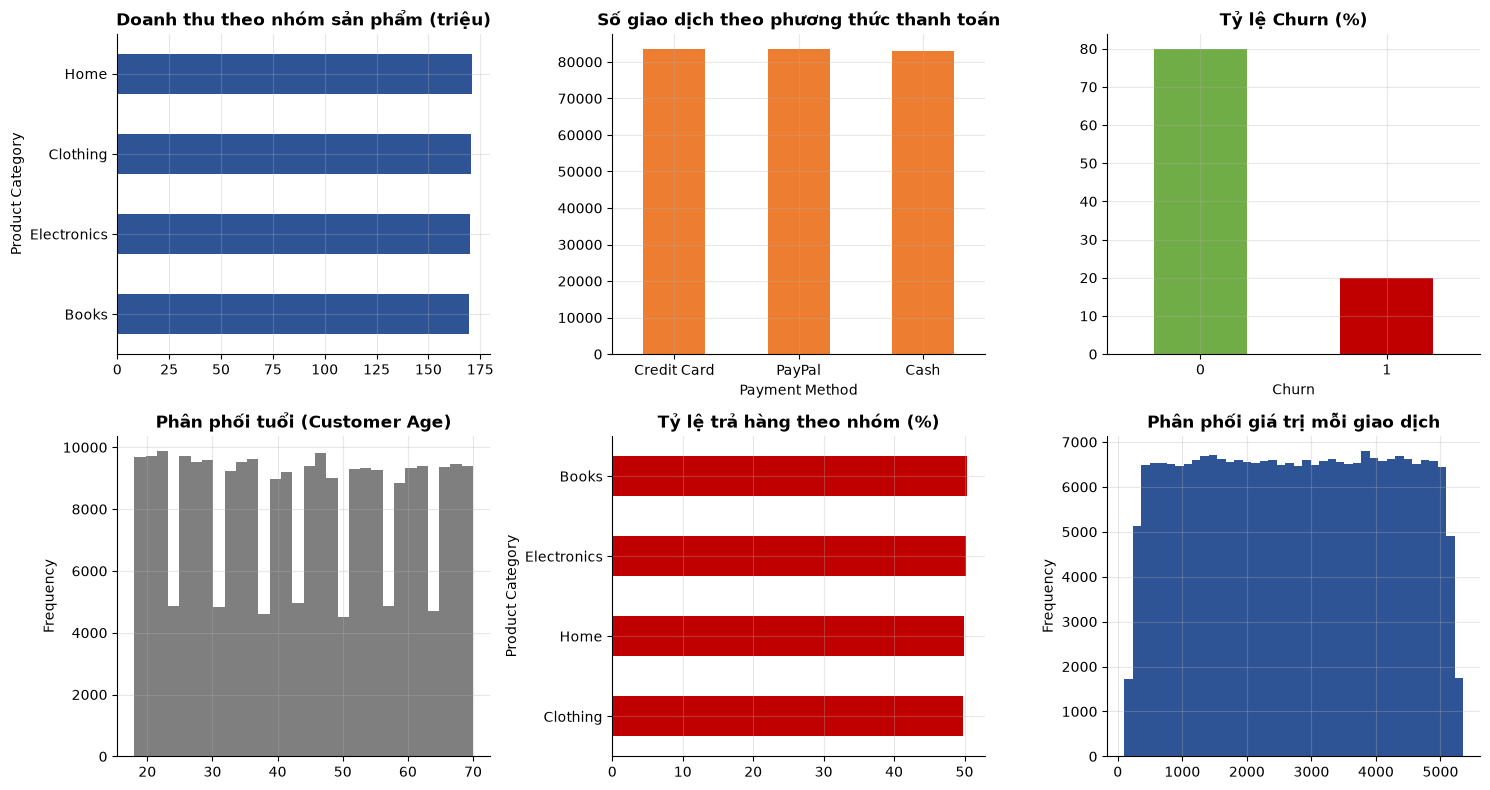

In [7]:
# --- Trực quan hóa dữ liệu giao dịch ---
age_col = "Customer Age" if "Customer Age" in df.columns else ("Age" if "Age" in df.columns else None)
panels = []
if "Product Category" in df.columns: panels.append("cat_rev")
if "Payment Method" in df.columns:   panels.append("pay")
if "Churn" in df.columns:            panels.append("churn")
if age_col:                          panels.append("age")
if {"Product Category", "Returns"} <= set(df.columns): panels.append("ret")
panels.append("amount")

ncols = 3; nrows = math.ceil(len(panels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows)); axes = np.atleast_1d(axes).ravel()
for ax, p in zip(axes, panels):
    if p == "cat_rev":
        s = df.groupby("Product Category")["Total Purchase Amount"].sum().sort_values()
        (s / 1e6).plot.barh(ax=ax, color="#2F5496"); ax.set_title("Doanh thu theo nhóm sản phẩm (triệu)")
    elif p == "pay":
        df["Payment Method"].value_counts().plot.bar(ax=ax, color="#ED7D31"); ax.set_title("Số giao dịch theo phương thức thanh toán")
        ax.tick_params(axis="x", rotation=0)
    elif p == "churn":
        df["Churn"].value_counts(normalize=True).sort_index().mul(100).plot.bar(ax=ax, color=["#70AD47", "#C00000"][:df["Churn"].nunique()])
        ax.set_title("Tỷ lệ Churn (%)"); ax.tick_params(axis="x", rotation=0)
    elif p == "age":
        df[age_col].plot.hist(bins=30, ax=ax, color="#7F7F7F"); ax.set_title(f"Phân phối tuổi ({age_col})")
    elif p == "ret":
        (df.groupby("Product Category")["Returns"].mean() * 100).sort_values().plot.barh(ax=ax, color="#C00000")
        ax.set_title("Tỷ lệ trả hàng theo nhóm (%)")
    elif p == "amount":
        df["Total Purchase Amount"].plot.hist(bins=40, ax=ax, color="#2F5496"); ax.set_title("Phân phối giá trị mỗi giao dịch")
for ax in axes[len(panels):]: ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Xây dựng chuỗi thời gian theo ngày và kiểm tra cấu trúc
RNN chỉ có ích khi chuỗi có phụ thuộc theo thời gian. Ta kiểm tra **xu hướng, mùa vụ theo thứ, tự tương quan (ACF)**.

In [8]:
# ---- Tổng hợp giao dịch thành chuỗi thời gian theo NGÀY ----
orders = df.set_index("Purchase Date").sort_index()
daily = orders.resample("D").agg(
    revenue=("Total Purchase Amount", "sum"),
    orders=("Total Purchase Amount", "size"),
    avg_order=("Total Purchase Amount", "mean"),
)
daily["return_rate"] = orders["Returns"].resample("D").mean() if "Returns" in orders.columns else 0.0
daily[["avg_order", "return_rate"]] = daily[["avg_order", "return_rate"]].ffill().bfill()   # ngày không có đơn
n_empty = int((daily["orders"] == 0).sum())

def calendar_feats(idx):
    """Đặc trưng lịch (biết trước cả trong tương lai): mã hóa vòng bằng sin/cos."""
    dow = np.asarray(idx.dayofweek); mon = np.asarray(idx.month) - 1
    return pd.DataFrame({
        "dow_sin": np.sin(2 * np.pi * dow / 7),  "dow_cos": np.cos(2 * np.pi * dow / 7),
        "month_sin": np.sin(2 * np.pi * mon / 12), "month_cos": np.cos(2 * np.pi * mon / 12),
    }, index=idx)

daily = daily.join(calendar_feats(daily.index))
print(f"Chuỗi theo ngày: {len(daily)} ngày | Ngày không có giao dịch: {n_empty}")
display(daily.head())
display(daily[["revenue", "orders", "avg_order", "return_rate"]].describe().T)

Chuỗi theo ngày: 1352 ngày | Ngày không có giao dịch: 0


,revenue,orders,avg_order,return_rate,dow_sin,dow_cos,month_sin,month_cos
Purchase Date,,,,,,,,
2020-01-01,464688,179,"2,596.0223",0.5143,0.9749,-0.2225,0.0000,1.0000
2020-01-02,546673,196,"2,789.1480",0.5427,0.4339,-0.9010,0.0000,1.0000
2020-01-03,498883,176,"2,834.5625",0.5105,-0.4339,-0.9010,0.0000,1.0000
2020-01-04,504343,186,"2,711.5215",0.5031,-0.9749,-0.2225,0.0000,1.0000
2020-01-05,500861,190,"2,636.1105",0.5064,-0.7818,0.6235,0.0000,1.0000


,count,mean,std,min,25%,50%,75%,max
revenue,"1,352.0000","503,954.3632","42,592.3069","357,710.0000","474,821.0000","504,141.5000","530,477.5000","649,755.0000"
orders,"1,352.0000",184.9112,14.0778,136.0000,175.0000,185.0000,194.0000,235.0000
avg_order,"1,352.0000","2,725.5420",103.7020,"2,307.8065","2,653.5183","2,729.0090","2,798.9239","3,042.5223"
return_rate,"1,352.0000",0.5008,0.0401,0.3608,0.4730,0.5000,0.5295,0.6479


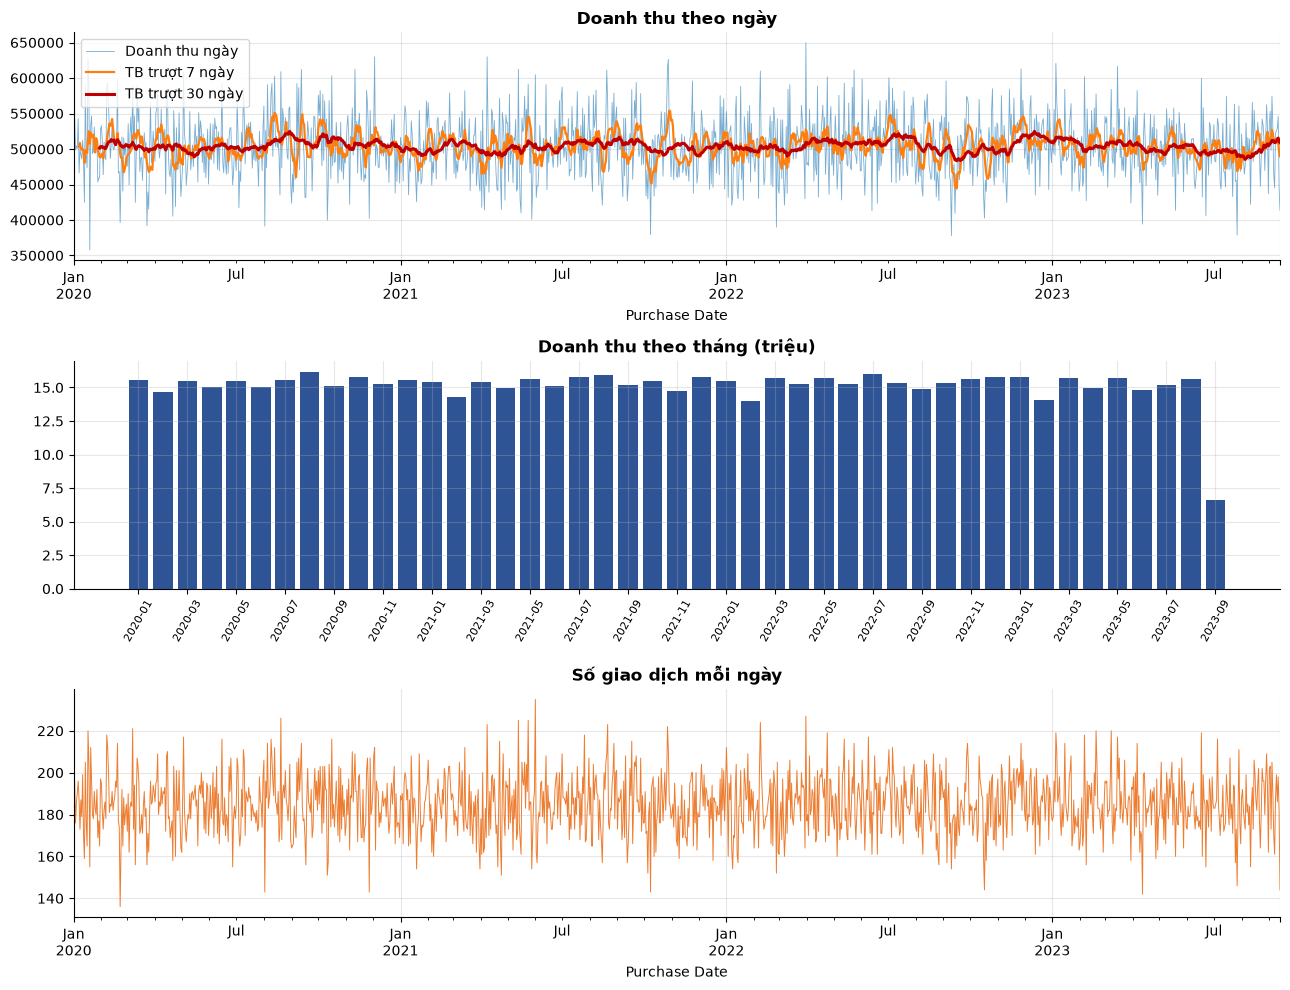

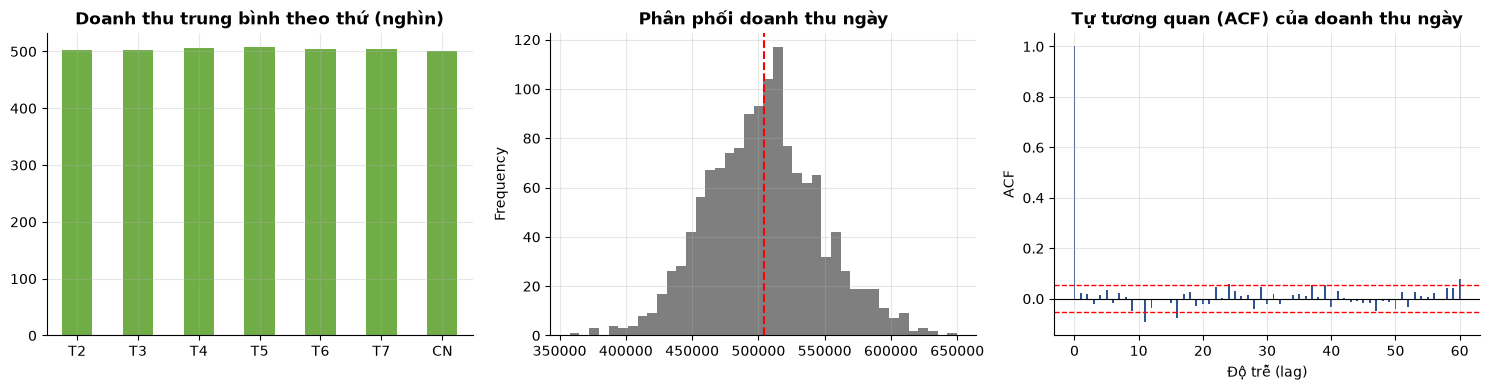

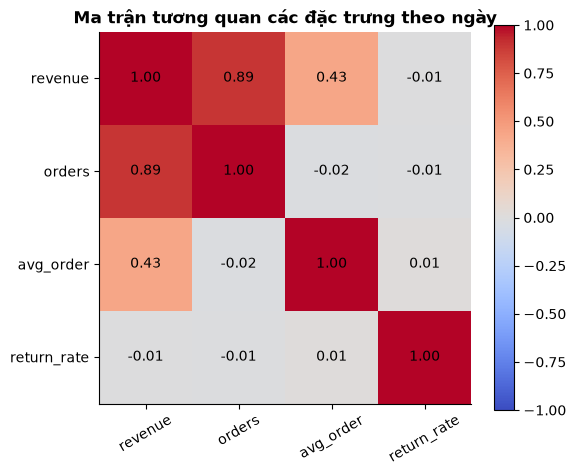

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False)
daily["revenue"].plot(ax=axes[0], lw=0.6, alpha=0.6, label="Doanh thu ngày")
daily["revenue"].rolling(7).mean().plot(ax=axes[0], lw=1.6, label="TB trượt 7 ngày")
daily["revenue"].rolling(30).mean().plot(ax=axes[0], lw=2.2, c="#C00000", label="TB trượt 30 ngày")
axes[0].set_title("Doanh thu theo ngày"); axes[0].legend(loc="upper left")
monthly = daily["revenue"].resample("MS").sum() / 1e6
axes[1].bar(range(len(monthly)), monthly.values, color="#2F5496")
step = max(1, len(monthly) // 20)
axes[1].set_xticks(range(0, len(monthly), step))
axes[1].set_xticklabels([d.strftime("%Y-%m") for d in monthly.index[::step]], rotation=60, fontsize=8)
axes[1].set_title("Doanh thu theo tháng (triệu)")
daily["orders"].plot(ax=axes[2], lw=0.7, c="#ED7D31"); axes[2].set_title("Số giao dịch mỗi ngày")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
wd = daily.groupby(daily.index.dayofweek)["revenue"].mean()
wd.index = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
(wd / 1e3).plot.bar(ax=axes[0], color="#70AD47"); axes[0].set_title("Doanh thu trung bình theo thứ (nghìn)")
axes[0].tick_params(axis="x", rotation=0)
daily["revenue"].plot.hist(bins=40, ax=axes[1], color="#7F7F7F"); axes[1].set_title("Phân phối doanh thu ngày")
axes[1].axvline(daily["revenue"].mean(), c="r", ls="--")
a, conf = plot_acf(axes[2], daily["revenue"], 60, "Tự tương quan (ACF) của doanh thu ngày")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
cm = daily[["revenue", "orders", "avg_order", "return_rate"]].corr()
im = ax.imshow(cm, cmap="coolwarm", vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(4)); ax.set_xticklabels(cm.columns, rotation=30); ax.set_yticks(range(4)); ax.set_yticklabels(cm.columns)
for i in range(4):
    for j in range(4): ax.text(j, i, f"{cm.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title("Ma trận tương quan các đặc trưng theo ngày"); plt.colorbar(im); plt.show()

In [10]:
# ---- Nhận định tự động về cấu trúc chuỗi (quyết định RNN có "đất diễn" hay không) ----
x = daily["revenue"].values
n = len(x)
sig_lags = [k for k in range(1, 31) if abs(a[k]) > conf]
slope = np.polyfit(np.arange(n), x, 1)[0] * 365
wd_cv = wd.std() / wd.mean()
print(f"- Tự tương quan lag-1 = {a[1]:.3f}, lag-7 = {a[7]:.3f} (ngưỡng ý nghĩa ±{conf:.3f})")
print(f"- Các lag (1-30) có ý nghĩa thống kê: {sig_lags if sig_lags else 'không có'}")
print(f"- Xu hướng tuyến tính: {slope:,.0f} đơn vị doanh thu/năm ({slope / x.mean():+.1%} so với mức trung bình)")
print(f"- Chênh lệch giữa các thứ trong tuần (hệ số biến thiên): {wd_cv:.1%}")
if not sig_lags and wd_cv < 0.05 and abs(slope / x.mean()) < 0.05:
    print("=> Chuỗi gần với nhiễu trắng: RNN khó vượt được mô hình cơ sở. Đây là một phát hiện hợp lệ, "
          "không phải lỗi mô hình (dữ liệu này là dữ liệu tổng hợp).")
else:
    print("=> Chuỗi có cấu trúc thời gian (tự tương quan/xu hướng/mùa vụ tuần): RNN có cơ sở để học.")

- Tự tương quan lag-1 = 0.024, lag-7 = 0.023 (ngưỡng ý nghĩa ±0.053)
- Các lag (1-30) có ý nghĩa thống kê: [11, 16, 24]
- Xu hướng tuyến tính: -513 đơn vị doanh thu/năm (-0.1% so với mức trung bình)
- Chênh lệch giữa các thứ trong tuần (hệ số biến thiên): 0.5%
=> Chuỗi có cấu trúc thời gian (tự tương quan/xu hướng/mùa vụ tuần): RNN có cơ sở để học.


## 4. Chia dữ liệu theo thời gian, chuẩn hóa và tạo cửa sổ trượt
- Chia **theo trình tự thời gian** (70% / 15% / 15%), không xáo trộn để tránh rò rỉ thông tin tương lai.
- `StandardScaler` chỉ được **fit trên tập huấn luyện**.
- Mỗi mẫu là tensor `(WINDOW, 8)`; nhãn là 4 đại lượng của ngày kế tiếp (doanh thu, số đơn, giá trị đơn TB, tỷ lệ trả hàng). Dự đoán đa đầu ra cho phép dự báo đệ quy nhiều ngày ở phần 9. Chỉ số đánh giá tập trung vào **doanh thu**.

Train: (916, 30, 8) | Val: (203, 30, 8) | Test: (203, 30, 8)
Train: 2020-01-31 -> 2022-08-03
Val  : 2022-08-04 -> 2023-02-22
Test : 2023-02-23 -> 2023-09-13


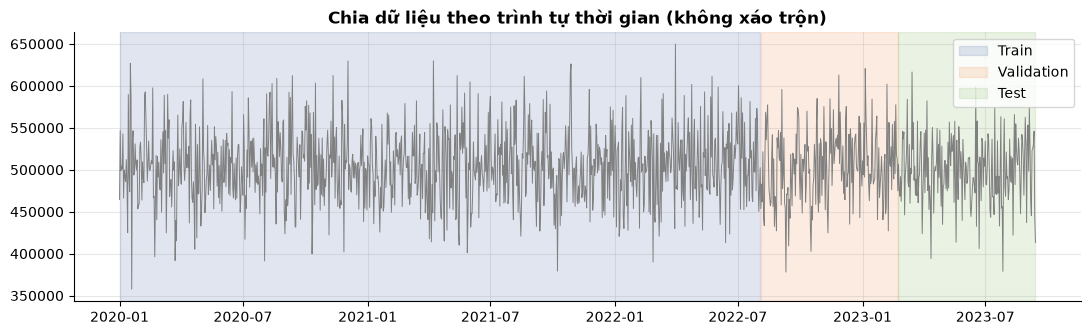

In [11]:
FEATURES = ["revenue", "orders", "avg_order", "return_rate", "dow_sin", "dow_cos", "month_sin", "month_cos"]
OUT_DIM = 4                       # mô hình dự đoán 4 đại lượng đầu tiên của ngày kế tiếp
N_FEATURES = len(FEATURES)

arr = daily[FEATURES].values.astype("float32")
n = len(arr)
i1, i2 = int(n * TRAIN_RATIO), int(n * (TRAIN_RATIO + VAL_RATIO))     # mốc chia THEO THỜI GIAN

scaler = StandardScaler().fit(arr[:i1])          # chỉ ước lượng trên tập huấn luyện -> không rò rỉ
arr_s = scaler.transform(arr).astype("float32")
inv_rev = lambda z: z * scaler.scale_[0] + scaler.mean_[0]     # đưa doanh thu về đơn vị gốc

X_all, y_all, pos = [], [], []
for i in range(WINDOW, n):
    X_all.append(arr_s[i - WINDOW:i])        # WINDOW ngày trước đó
    y_all.append(arr_s[i, :OUT_DIM])         # đặc trưng của ngày i
    pos.append(i)
X_all, y_all, pos = np.array(X_all, "float32"), np.array(y_all, "float32"), np.array(pos)

m_tr, m_va, m_te = pos < i1, (pos >= i1) & (pos < i2), pos >= i2
X_train, y_train = X_all[m_tr], y_all[m_tr]
X_val,   y_val   = X_all[m_va], y_all[m_va]
X_test,  y_test  = X_all[m_te], y_all[m_te]
raw_rev = daily["revenue"].values
dates = daily.index

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train: {dates[WINDOW].date()} -> {dates[i1 - 1].date()}")
print(f"Val  : {dates[i1].date()} -> {dates[i2 - 1].date()}")
print(f"Test : {dates[i2].date()} -> {dates[-1].date()}")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(dates, raw_rev, lw=0.7, c="gray")
for lo, hi, c, lb in [(0, i1, "#2F5496", "Train"), (i1, i2, "#ED7D31", "Validation"), (i2, n, "#70AD47", "Test")]:
    ax.axvspan(dates[lo], dates[hi - 1], color=c, alpha=0.15, label=lb)
ax.set_title("Chia dữ liệu theo trình tự thời gian (không xáo trộn)"); ax.legend(); plt.show()

## 5. Mô hình cơ sở (baseline)
Mọi mô hình RNN phải được so với hai baseline đơn giản: *Naive* (doanh thu hôm qua) và *trung bình 7 ngày*.

In [12]:
def rmse(y, p): return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))
def mae(y, p):  return float(np.mean(np.abs(np.asarray(y) - np.asarray(p))))
def mape(y, p):
    y, p = np.asarray(y), np.asarray(p); m = y > 0
    return float(np.mean(np.abs((y[m] - p[m]) / y[m])) * 100)
def r2(y, p):
    y, p = np.asarray(y), np.asarray(p)
    return float(1 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2))

split_pos = {"val": pos[m_va], "test": pos[m_te]}
rev_true = {k: raw_rev[v] for k, v in split_pos.items()}
preds = {"val": {}, "test": {}}
for k, v in split_pos.items():
    preds[k]["Naive (hôm qua)"] = raw_rev[v - 1]                                   # doanh thu ngày liền trước
    preds[k]["TB 7 ngày"] = np.array([raw_rev[p - 7:p].mean() for p in v])        # trung bình 7 ngày gần nhất
print("Baseline tập test ->", {k: round(rmse(rev_true['test'], v), 1) for k, v in preds['test'].items()})

Baseline tập test -> {'Naive (hôm qua)': 55658.1, 'TB 7 ngày': 41844.4}


## 6. Xây dựng và huấn luyện RNN / LSTM / GRU (Keras (TensorFlow))
Ba kiến trúc dùng **cùng siêu tham số** (2 lớp × `UNITS` đơn vị, dropout, Adam, MSE, dừng sớm, giảm learning rate khi chững) để so sánh công bằng.

In [13]:
def build_model(kind, input_shape, out_dim):
    """2 lớp RNN/LSTM/GRU xếp chồng + Dropout + đầu ra Dense."""
    Cell = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[kind]
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        Cell(UNITS, return_sequences=True),
        layers.Dropout(DROPOUT),
        Cell(UNITS),
        layers.Dropout(DROPOUT),
        layers.Dense(32, activation="relu"),
        layers.Dense(out_dim),
    ], name=kind)
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
    return model

def train_model(kind, X_tr, y_tr, X_va, y_va):
    keras.utils.set_random_seed(SEED)
    model = build_model(kind, X_tr.shape[1:], y_tr.shape[1])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(3, PATIENCE // 3), min_lr=1e-5),
    ]
    h = model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=EPOCHS,
                  batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1)
    n_ep = len(h.history["loss"])
    print(f"{kind:5s} | dừng sau {n_ep:3d} epoch | val_loss tốt nhất = {min(h.history['val_loss']):.4f} "
          f"| số tham số = {model.count_params():,}")
    return model, {"loss": h.history["loss"], "val_loss": h.history["val_loss"]}

def predict_scaled(model, X):
    """Dự đoán trên không gian đã chuẩn hóa, trả về mảng (n_mẫu, out_dim)."""
    return model.predict(X, batch_size=256, verbose=1).reshape(len(X), -1)

# Xem cấu trúc một mô hình mẫu
build_model("LSTM", (WINDOW, N_FEATURES), OUT_DIM).summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,924 (210.64 KB)

 Trainable params: 53,924 (210.64 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
KINDS = ["RNN", "LSTM", "GRU"]
models, histories = {}, {}
for kind in KINDS:
    models[kind], histories[kind] = train_model(kind, X_train, y_train, X_val, y_val)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 1.2295 - val_loss: 1.1163 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0759 - val_loss: 1.1091 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0294 - val_loss: 1.1026 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0049 - val_loss: 1.0971 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.0061 - val_loss: 1.0966 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9700 - val_loss: 1.1019 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9769 - val_loss: 1.0976 - learning_rate: 0.0010
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9540 - val_loss: 1.0867 - learning_rate: 0.0010
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.9357 - val_loss: 1.0951 - learning_rate: 0.0010
Epoch 10/1

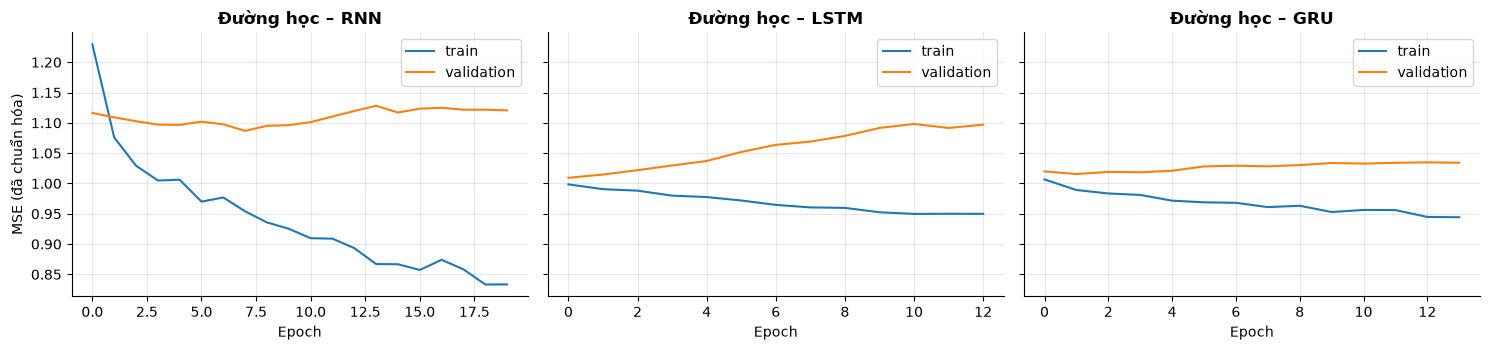

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, kind in zip(axes, KINDS):
    ax.plot(histories[kind]["loss"], label="train"); ax.plot(histories[kind]["val_loss"], label="validation")
    ax.set_title(f"Đường học – {kind}"); ax.set_xlabel("Epoch"); ax.legend()
axes[0].set_ylabel("MSE (đã chuẩn hóa)")
plt.tight_layout(); plt.show()

## 7. Đánh giá và trực quan hóa dự đoán
Bảng chỉ số, biểu đồ dự đoán so với thực tế và phân tích phần dư. Mô hình "tốt nhất" được chọn theo **tập kiểm định** để tập kiểm thử vẫn là phép đo độc lập.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


,RMSE val,RMSE test,MAE test,MAPE test (%),R² test
Mô hình,,,,,
LSTM,"42,721.3917","39,317.8920","31,227.2235",6.3999,-0.0209
GRU,"43,104.1923","39,683.9119","31,326.1298",6.4383,-0.0400
RNN,"45,442.9649","40,874.6293","32,568.8247",6.6950,-0.1034
TB 7 ngày,"45,189.3939","41,844.4026","32,771.7424",6.6565,-0.1563
Naive (hôm qua),"55,250.8168","55,658.1393","44,753.7635",9.0211,-1.0458


Mô hình tốt nhất trên tập kiểm định: LSTM


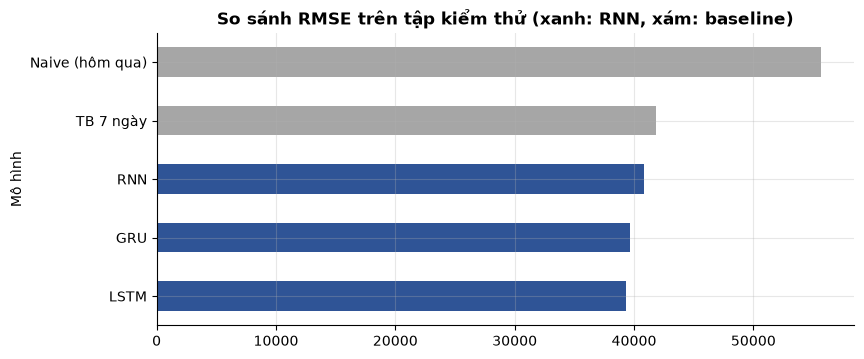

In [16]:
for kind in KINDS:
    for k, X in [("val", X_val), ("test", X_test)]:
        preds[k][kind] = inv_rev(predict_scaled(models[kind], X)[:, 0])

rows = []
for name in preds["test"]:
    rows.append({
        "Mô hình": name,
        "RMSE val": rmse(rev_true["val"], preds["val"][name]),
        "RMSE test": rmse(rev_true["test"], preds["test"][name]),
        "MAE test": mae(rev_true["test"], preds["test"][name]),
        "MAPE test (%)": mape(rev_true["test"], preds["test"][name]),
        "R² test": r2(rev_true["test"], preds["test"][name]),
    })
results = pd.DataFrame(rows).set_index("Mô hình")
display(results.sort_values("RMSE test"))

best_kind = min(KINDS, key=lambda k: results.loc[k, "RMSE val"])     # chọn mô hình theo tập KIỂM ĐỊNH
print(f"Mô hình tốt nhất trên tập kiểm định: {best_kind}")

fig, ax = plt.subplots(figsize=(9, 3.8))
results["RMSE test"].sort_values().plot.barh(ax=ax, color=["#2F5496" if i in KINDS else "#A6A6A6" for i in results["RMSE test"].sort_values().index])
ax.set_title("So sánh RMSE trên tập kiểm thử (xanh: RNN, xám: baseline)"); plt.show()

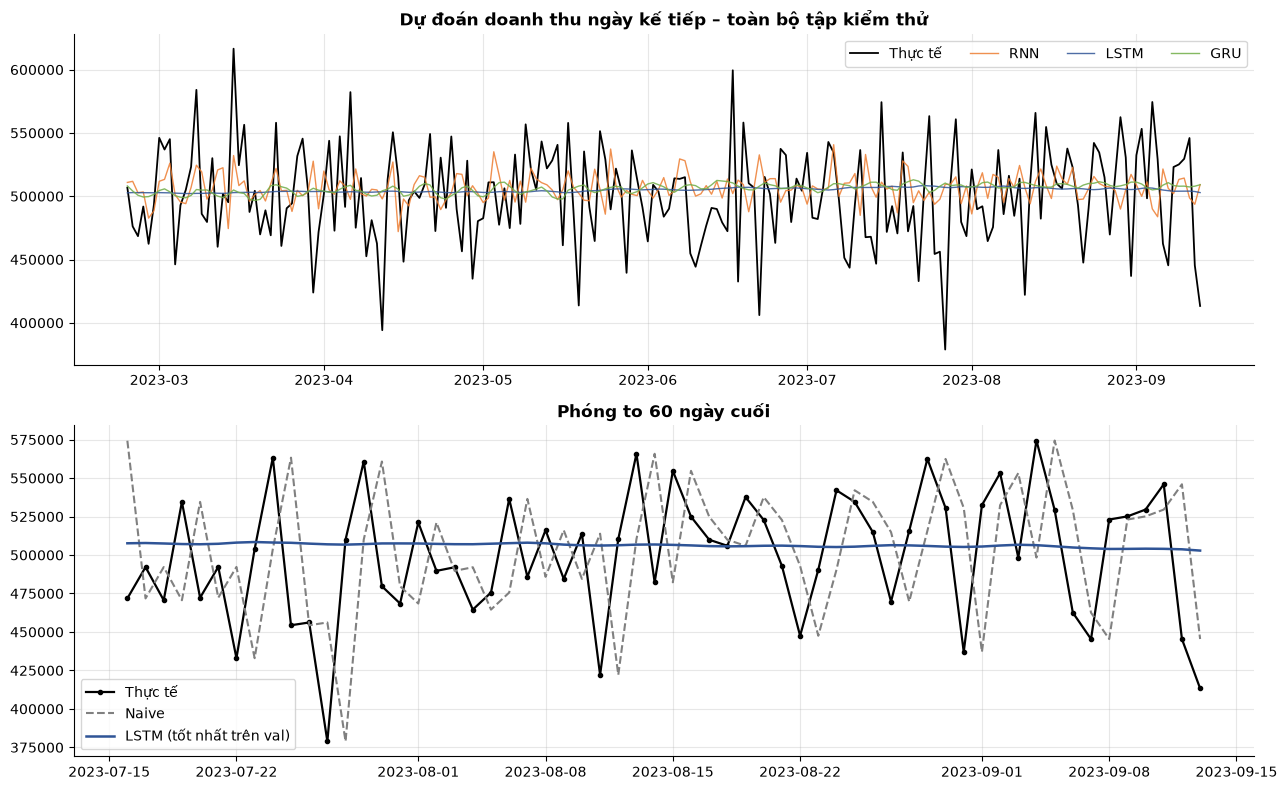

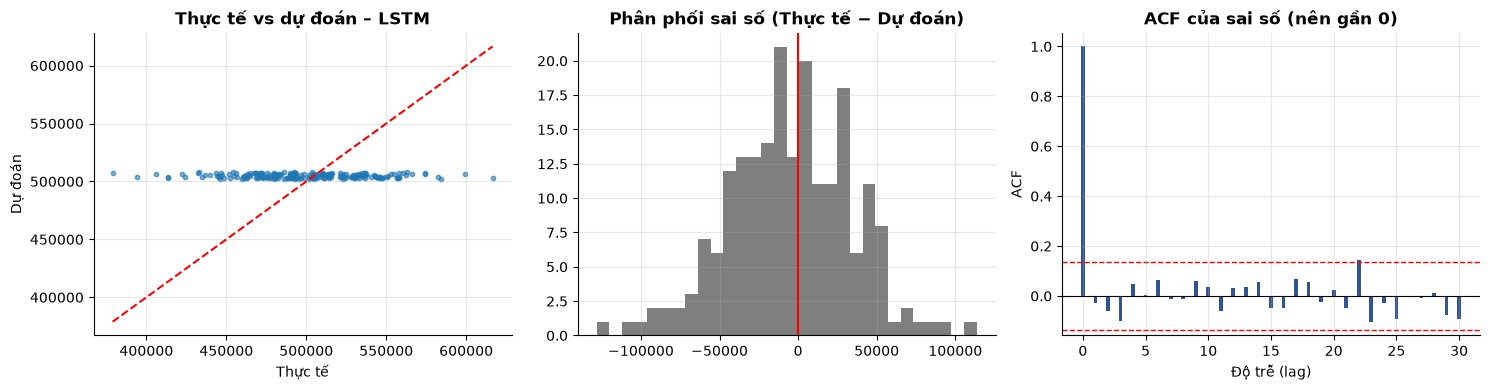

Sai số trung bình (bias) = -4,839.8 | độ lệch chuẩn sai số = 39,018.9


In [17]:
d_test = dates[split_pos["test"]]
colors = {"RNN": "#ED7D31", "LSTM": "#2F5496", "GRU": "#70AD47"}
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
axes[0].plot(d_test, rev_true["test"], c="k", lw=1.3, label="Thực tế")
for kind in KINDS: axes[0].plot(d_test, preds["test"][kind], c=colors[kind], lw=1, alpha=0.85, label=kind)
axes[0].set_title("Dự đoán doanh thu ngày kế tiếp – toàn bộ tập kiểm thử"); axes[0].legend(ncol=4)

zoom = slice(-60, None)
axes[1].plot(d_test[zoom], rev_true["test"][zoom], c="k", lw=1.6, marker="o", ms=3, label="Thực tế")
axes[1].plot(d_test[zoom], preds["test"]["Naive (hôm qua)"][zoom], c="gray", ls="--", label="Naive")
axes[1].plot(d_test[zoom], preds["test"][best_kind][zoom], c=colors[best_kind], lw=1.8, label=f"{best_kind} (tốt nhất trên val)")
axes[1].set_title("Phóng to 60 ngày cuối"); axes[1].legend(); plt.tight_layout(); plt.show()

# --- Phân tích sai số của mô hình tốt nhất ---
res = rev_true["test"] - preds["test"][best_kind]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(rev_true["test"], preds["test"][best_kind], s=10, alpha=0.6)
lim = [min(rev_true["test"].min(), preds["test"][best_kind].min()), max(rev_true["test"].max(), preds["test"][best_kind].max())]
axes[0].plot(lim, lim, "r--"); axes[0].set_xlabel("Thực tế"); axes[0].set_ylabel("Dự đoán"); axes[0].set_title(f"Thực tế vs dự đoán – {best_kind}")
axes[1].hist(res, bins=30, color="#7F7F7F"); axes[1].axvline(0, c="r"); axes[1].set_title("Phân phối sai số (Thực tế − Dự đoán)")
plot_acf(axes[2], res, 30, "ACF của sai số (nên gần 0)")
plt.tight_layout(); plt.show()
print(f"Sai số trung bình (bias) = {res.mean():,.1f} | độ lệch chuẩn sai số = {res.std():,.1f}")

## 8. Phân tích đặc trưng nào quan trọng
Xáo trộn từng đặc trưng trong tập kiểm thử; đặc trưng nào làm RMSE tăng nhiều nhất là đặc trưng mô hình dựa vào nhiều nhất.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━

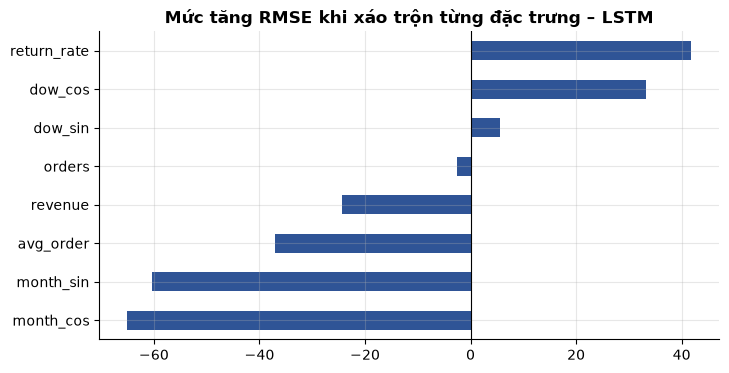

Đặc trưng ảnh hưởng nhất: return_rate | mức tăng RMSE ≈ 41.8


In [18]:
# ---- Độ quan trọng đặc trưng bằng hoán vị (permutation importance) trên tập kiểm thử ----
base_rmse = rmse(rev_true["test"], preds["test"][best_kind])
rng = np.random.default_rng(SEED)
imp = {}
for j, name in enumerate(FEATURES):
    deltas = []
    for _ in range(5):
        Xp = X_test.copy()
        Xp[:, :, j] = Xp[rng.permutation(len(Xp))][:, :, j]     # xáo trộn đặc trưng j giữa các mẫu
        deltas.append(rmse(rev_true["test"], inv_rev(predict_scaled(models[best_kind], Xp)[:, 0])) - base_rmse)
    imp[name] = np.mean(deltas)
imp = pd.Series(imp).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax, color="#2F5496"); ax.axvline(0, c="k", lw=0.8)
ax.set_title(f"Mức tăng RMSE khi xáo trộn từng đặc trưng – {best_kind}"); plt.show()
print("Đặc trưng ảnh hưởng nhất:", imp.idxmax(), "| mức tăng RMSE ≈ %.1f" % imp.max())

## 9. Dự báo tương lai
Dự báo đệ quy `HORIZON` ngày sau ngày cuối cùng của dữ liệu bằng mô hình tốt nhất.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


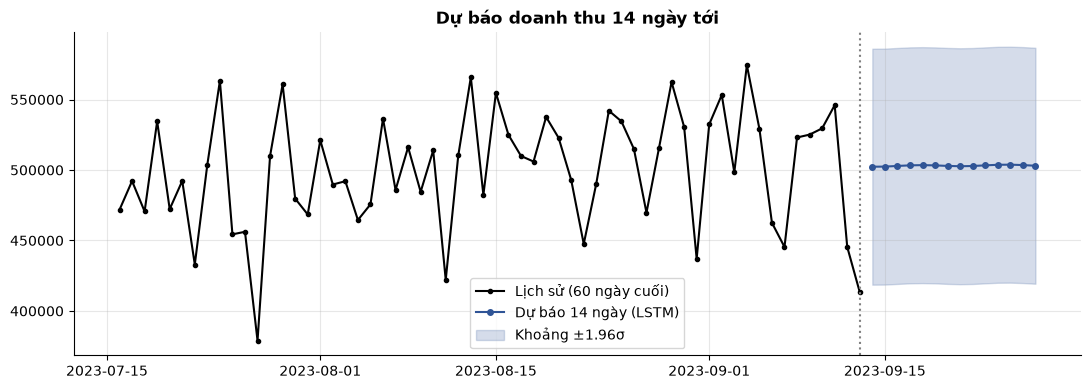

,Doanh thu dự báo,Cận dưới (95%),Cận trên (95%)
Ngày,,,
2023-09-14,"502,347.0000","418,637.0000","586,058.0000"
2023-09-15,"502,414.0000","418,704.0000","586,124.0000"
2023-09-16,"502,878.0000","419,168.0000","586,588.0000"
2023-09-17,"503,308.0000","419,598.0000","587,019.0000"
2023-09-18,"503,458.0000","419,747.0000","587,168.0000"
2023-09-19,"503,283.0000","419,573.0000","586,994.0000"
2023-09-20,"502,903.0000","419,193.0000","586,613.0000"
2023-09-21,"502,677.0000","418,967.0000","586,387.0000"
2023-09-22,"502,839.0000","419,129.0000","586,550.0000"


Lưu ý: dự báo đệ quy nhiều bước tích lũy sai số; khoảng tin cậy chỉ mang tính tham khảo.


In [19]:
def forecast_future(model, horizon):
    """Dự báo đệ quy: đưa dự đoán của ngày t làm đầu vào cho ngày t+1. Đặc trưng lịch được biết trước."""
    window = arr_s[-WINDOW:].copy()
    rows = []
    for h in range(1, horizon + 1):
        d = dates[-1] + pd.Timedelta(days=h)
        p = predict_scaled(model, window[None, ...])[0]                      # (OUT_DIM,) đã chuẩn hóa
        cal = calendar_feats(pd.DatetimeIndex([d])).values[0]
        cal_s = (cal - scaler.mean_[OUT_DIM:]) / scaler.scale_[OUT_DIM:]
        window = np.vstack([window[1:], np.concatenate([p, cal_s]).astype("float32")])
        rows.append((d, float(inv_rev(p[0]))))
    return pd.DataFrame(rows, columns=["Ngày", "Doanh thu dự báo"]).set_index("Ngày")

fc = forecast_future(models[best_kind], HORIZON)
sigma = (rev_true["val"] - preds["val"][best_kind]).std()          # độ lệch chuẩn sai số trên tập val
fc["Cận dưới (95%)"] = fc["Doanh thu dự báo"] - 1.96 * sigma
fc["Cận trên (95%)"] = fc["Doanh thu dự báo"] + 1.96 * sigma

hist_tail = daily["revenue"].iloc[-60:]
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(hist_tail.index, hist_tail.values, c="k", marker="o", ms=3, label="Lịch sử (60 ngày cuối)")
ax.plot(fc.index, fc["Doanh thu dự báo"], c=colors[best_kind], marker="o", ms=4, label=f"Dự báo {HORIZON} ngày ({best_kind})")
ax.fill_between(fc.index, fc["Cận dưới (95%)"], fc["Cận trên (95%)"], color=colors[best_kind], alpha=0.2, label="Khoảng ±1.96σ")
ax.axvline(dates[-1], c="gray", ls=":"); ax.set_title(f"Dự báo doanh thu {HORIZON} ngày tới"); ax.legend(); plt.show()
display(fc.round(0))
print("Lưu ý: dự báo đệ quy nhiều bước tích lũy sai số; khoảng tin cậy chỉ mang tính tham khảo.")

## 10. Kết luận

In [20]:
# ---- Kết luận tự động dựa trên kết quả thực tế ----
best_rmse = results.loc[best_kind, "RMSE test"]
naive_rmse = results.loc["Naive (hôm qua)", "RMSE test"]
ma_rmse = results.loc["TB 7 ngày", "RMSE test"]
gain = (1 - best_rmse / min(naive_rmse, ma_rmse)) * 100
print(f"RMSE test – {best_kind}: {best_rmse:,.0f} | Naive: {naive_rmse:,.0f} | TB 7 ngày: {ma_rmse:,.0f}")
if gain > 3:
    print(f"=> {best_kind} tốt hơn baseline tốt nhất khoảng {gain:.1f}%: chuỗi có cấu trúc mà RNN khai thác được.")
elif gain > -3:
    print(f"=> {best_kind} chỉ tương đương baseline (chênh {gain:+.1f}%): RNN không mang lại lợi ích rõ rệt.")
else:
    print(f"=> {best_kind} kém baseline {abs(gain):.1f}%: nên ưu tiên mô hình đơn giản (trung bình trượt) cho chuỗi này.")
print("R² test của mô hình tốt nhất:", round(results.loc[best_kind, "R² test"], 3),
      "(gần 0 hoặc âm nghĩa là chưa giải thích được biến thiên ngoài mức trung bình)")

RMSE test – LSTM: 39,318 | Naive: 55,658 | TB 7 ngày: 41,844
=> LSTM tốt hơn baseline tốt nhất khoảng 6.0%: chuỗi có cấu trúc mà RNN khai thác được.
R² test của mô hình tốt nhất: -0.021 (gần 0 hoặc âm nghĩa là chưa giải thích được biến thiên ngoài mức trung bình)


### Cách đọc kết quả
- **RNN vs LSTM vs GRU:** RNN đơn giản dễ mất thông tin ở cửa sổ dài; LSTM/GRU có cổng nên thường ổn định hơn. Nếu ba mô hình cho kết quả gần nhau, hãy ưu tiên GRU vì ít tham số hơn.
- **So với baseline:** chỉ khi RMSE thấp hơn rõ rệt baseline thì mới có thể nói mô hình học được cấu trúc thời gian.
- **Hạn chế:** dữ liệu tổng hợp, nhãn không dùng ở bài này, dự báo đệ quy tích lũy sai số.
- **Hướng mở rộng:** thử `WINDOW` khác (7, 14, 60), dự báo theo tuần, thêm ngày lễ, hoặc chuyển sang bài toán phân loại churn theo chuỗi giao dịch của từng khách.